<a href="https://colab.research.google.com/github/felipe24I/AprendizajeMaquina/blob/main/Clasificadores_Clasicos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Clasificadores clasicos**

##**1. Naive Bayes Gaussiano**

Es un clasificador supervisado **probabilístico** basado en el **teorema de Bayes**, con una suposición de independencia **"naive"** entre las características, y una suposición adicional de que cada característica $X_i$ sigue una **distribución normal** dentro de cada clase $C_k$.

---

## Modelo

Dado un conjunto de datos con:

- Un vector de características $X = (X_1, X_2, ..., X_n)$
- Una variable de clase $y \in \{ C_1, C_2, ..., C_k \}$

Se quiere predecir la clase más probable, y dado $x$:

$$
\hat{y} = \arg\max_{C_k} P(C_k | X)
$$

Por el **teorema de Bayes**:

$$
P(C_k | X) = \frac{P(X | C_k) \cdot P(C_k)}{P(X)}
$$

Como $P(X)$ es común para todas las clases, basta con **maximizar el numerador**:

$$
\hat{y} = \arg\max_{C_k} P(X | C_k) \cdot P(C_k)
$$

---

## Suposición de Independencia

Con la suposición *naive* de independencia condicional entre características:

$$
P(X | C_k) = P(X_1, X_2, ..., X_n | C_k) = \prod_{i=1}^{n} P(X_i | C_k)
$$

---

## Suposición Gaussiana

Bajo la suposición gaussiana, cada característica $X_i$ **condicional a la clase $C_k$** sigue una distribución normal:

$$
P(X_i | C_k) = \frac{1}{\sqrt{2\pi \sigma_{ik}^2}} \exp\left( - \frac{(X_i - \mu_{ik})^2}{2\sigma_{ik}^2} \right)
$$

Donde:

- $\mu_{ik}$: media de la característica $X_i$ en la clase $C_k$
- $\sigma_{ik}^2$: varianza de $X_i$ en la clase $C_k$

---

## Estimación Cerrada de Parámetros

### Probabilidad a priori de cada clase:

$$
P(C_k) = \frac{\text{número de muestras en clase } C_k}{\text{total de muestras}}
$$

### Parámetros de la distribución gaussiana para cada característica $X_i$ en cada clase $C_k$:

$$
\mu_{ik} = \frac{1}{N_k} \sum_{j : y_j = C_k} x_{ij}
$$

$$
\sigma_{ik}^2 = \frac{1}{N_k} \sum_{j : y_j = C_k} (x_{ij} - \mu_{ik})^2
$$

Donde:

- $N_k$: número de muestras que pertenecen a la clase $C_k$
- $x_{ij}$: valor de la característica $i$ en la muestra $j$

La suma se hace **solo sobre los datos cuya etiqueta $y_j$ sea la clase $C_k$**.


## **2. SGD Classifier**

Es un clasificador supervisado que entrena un modelo lineal (como regresión logística o SVM) usando **descenso de gradiente estocástico**.

---

### 🔧 Conceptos Clave

- **Descenso de gradiente**: método para minimizar una función de pérdida, actualizando los parámetros del modelo en la dirección que reduce el error.

- **Estocástico**: en lugar de usar todos los datos como en el descenso de gradiente clásico, se usa **una sola muestra** en cada paso, lo cual es más rápido.

---

## Modelo

El modelo es **lineal**:

$$
f(x) = W^T X + b
$$

Donde:

- $X \in \mathbb{R}^n$: vector de características  
- $W \in \mathbb{R}^n$: pesos del modelo  
- $b \in \mathbb{R}$: sesgo (bias)  

**Interpretaciones**:

- $W$: determina la **orientación** del hiperplano
- $b$: permite a la **frontera de decisión** moverse hacia arriba o abajo (como un desplazamiento vertical en 2D)

---

### 📈 Predicción

La predicción depende del signo de $f(x)$:

- Si $f(x) > 0$: predice la clase 1  
- Si $f(x) < 0$: predice la clase 0  

---

Un modelo lineal traza una frontera de decisión que es un **hiperplano** (una recta en 2D, un plano en 3D, etc.) que separa las clases.

**Ejemplo en 2D**: la frontera es:

$$
W_1 X_1 + W_2 X_2 + b = 0
$$

Lo cual es una **línea recta**.

---

## Objetivo / Problema de Optimización

El SGD Classifier intenta minimizar la **función de pérdida promedio** sobre todos los datos:

$$
\min_{W, b} \ \frac{1}{m} \sum_{i=1}^{m} L(y_i, f(x_i)) + \lambda R(W)
$$

Donde:

- $L(y_i, f(x_i))$: función de pérdida
- $y_i$: etiqueta real de la muestra $i$
- $x_i$: vector de características de la muestra $i$
- $f(x_i)$: salida del modelo ($W^T x_i + b$)
- $R(W)$: término de regularización (ej. $L_2 = ||W||^2$, $L_1 = ||W||$)
- $\lambda$: fuerza de regularización

---

## ¿Cómo se resuelve?

En lugar de calcular el gradiente sobre todos los datos (como en el descenso de gradiente clásico), **SGD hace lo siguiente**:

1. Toma una muestra aleatoria $(x_i, y_i)$  
2. Calcula el gradiente de la pérdida con esa muestra:  
   - $\nabla W_i = \partial L_i / \partial W$  
   - $\nabla b_i = \partial L_i / \partial b$  
3. Se actualiza $W$ y $b$:

$$
W \leftarrow W - \eta \cdot \nabla W_i
$$

$$
b \leftarrow b - \eta \cdot \nabla b_i
$$

Donde:

- $\eta$ es la **tasa de aprendizaje**
- $L_i$ es la **pérdida en la muestra $i$**

---

##**3. Regresión Logística**

Es un modelo lineal de clasificación **binaria**, diseñado para predecir la **probabilidad** de que una muestra pertenezca a una clase.

---

## Modelo

Dado un vector de características $x \in \mathbb{R}^n$, se quiere predecir:

$$
P(y = 1 | x) = \sigma(W^T x + b)
$$

Donde:

- $W \in \mathbb{R}^n$: vector de pesos  
- $b \in \mathbb{R}$: sesgo (bias)  
- $\sigma(z) = \frac{1}{1 + e^{-z}}$: función sigmoide o logística

Esto da una salida entre 0 y 1, interpretada como una **probabilidad**.

---

## Función de pérdida: log-loss (cross-entropy)

La función de pérdida para una muestra $(x_i, y_i)$ con $g_i = \sigma(W^T x_i + b)$ es:

$$
L(y_i, g_i) = -y_i \log(g_i) - (1 - y_i) \log(1 - g_i)
$$

Esto penaliza **fuertemente** las predicciones que están lejos de la etiqueta verdadera.

---

## Problema de optimización

Para un conjunto de entrenamiento de $m$ muestras:

$$
\min_{W, b} \ \frac{1}{m} \sum_{i=1}^{m} \left[ -y_i \log(g_i) - (1 - y_i) \log(1 - g_i) \right] + \lambda ||W||^2
$$

- El primer término es la **pérdida promedio** (log-loss)  
- El segundo término es la **regularización L2**, que controla el sobreajuste

---

## Derivadas (gradientes)

Para una sola muestra, con $z = W^T x + b$:

- $\sigma(z) = \frac{1}{1 + e^{-z}}$
- $L(W, b) = -y \log(\sigma(z)) - (1 - y) \log(1 - \sigma(z))$

**Gradientes**:

- Respecto a $W$:
  $$
  \nabla_W L = (\sigma(z) - y) \cdot x
  $$
- Respecto a $b$:
  $$
  \nabla_b L = \sigma(z) - y
  $$

---

## Regla de actualización por descenso de gradiente

$$
W \leftarrow W - \eta \cdot \nabla_W L
$$

$$
b \leftarrow b - \eta \cdot \nabla_b L
$$

Donde $\eta$ es la **tasa de aprendizaje**.

##**4. Linear Discriminant Analysis (LDA)**

LDA es un clasificador **supervisado lineal** que:

- Asume que los datos de cada clase siguen una **distribución gaussiana** con la **misma matriz de covarianza**.
- Busca proyectar los datos en una dirección que **maximice la separación entre clases** (discriminación).
- Se basa en principios **probabilísticos** y genera una **proyección lineal**.

---

### Supuestos clave

1. Cada clase $C_k$ genera datos $X \in \mathbb{R}^d$ con una **distribución normal multivariada**:

   $$
   X \sim \mathcal{N}(\mu_k, \Sigma)
   $$

   Donde $\mu_k$ es la media de la clase y $\Sigma$ es la **misma matriz de covarianza** para todas las clases.

2. La matriz de covarianza es **igual para todas las clases**:

   $$
   \Sigma_1 = \Sigma_2 = \cdots = \Sigma
   $$

3. Se conoce o se estima la **probabilidad a priori** de cada clase $P(C_k)$.

---

## Modelo de LDA

LDA predice la clase como:

$$
\hat{y} = \arg\max_k \ \delta_k(x)
$$

Donde $\delta_k(x)$ es la **función discriminante lineal** para la clase $C_k$:

$$
\delta_k(x) = x^T \Sigma^{-1} \mu_k - \frac{1}{2} \mu_k^T \Sigma^{-1} \mu_k + \log P(C_k)
$$

---

### Propiedades

- La función $\delta_k(x)$ es **lineal en $x$**, por eso LDA es un **modelo lineal**.

## **5. K-Nearest Neighbors (KNN)**

Es un **clasificador supervisado no paramétrico**.

Esto significa que **no aprende una función o modelo durante el entrenamiento**, sino que guarda **todo el conjunto de entrenamiento**.

---

### ¿Cómo funciona?

Cuando llega un nuevo punto $x$, el modelo:

1. Calcula la **distancia** entre $x$ y todos los puntos del conjunto de entrenamiento  
2. Selecciona los **$k$ puntos más cercanos** (los vecinos)  
3. Asigna la clase más común entre esos vecinos a $x$

---

## Modelo del clasificador KNN

El modelo como tal es **implícito**, pero puede expresarse así:

Dado un conjunto de entrenamiento:

$$
D = \{ (x_1, y_1), (x_2, y_2), ..., (x_n, y_n) \}
$$

y una nueva muestra $x$, la predicción es:

$$
\hat{y} = \text{modo} \{ y_j \, | \, x_j \in N_k(x) \}
$$

Donde:

- $N_k(x)$: conjunto de los $k$ vecinos más cercanos a $x$ según alguna **métrica** (como distancia euclidiana)  
- **modo**: clase más frecuente entre los vecinos

---

## Criterio de optimización

KNN **no optimiza una función de costo explícita**, pero puede entenderse como un método que **minimiza el error de clasificación localmente**.

Formalmente:

$$
\hat{y}(x) = \arg\max_{c \in \text{clases}} \sum_{x_i \in N_k(x)} \mathbb{1}(y_i = c)
$$

Donde:

- $\mathbb{1}(y_i = c)$ es una función indicadora que vale 1 si el vecino $x_i$ tiene clase $c$, y 0 si no.
- $\hat{y}(x)$ es la clase que KNN va a predecir para el punto $x$.
- $c \in$ clases: se evalúa cada clase posible (ej. $0$, $1$, $perro$, $gato$, etc).

## **6. Linear SVC (Support Vector Classifier)**

Es un clasificador supervisado que busca encontrar un **hiperplano lineal** que **separe dos clases** con el **máximo margen posible**.

Es una versión lineal del **SVM (Support Vector Machine)**, pero entrenado generalmente con un enfoque más eficiente.

---

## Modelo

El modelo lineal es:

$$
f(x) = W^T x + b
$$

La predicción se hace como:

$$
\hat{y} = \text{sign}(W^T x + b)
$$

Donde:

- $W$: vector de pesos (dirección del hiperplano)  
- $b$: sesgo (desplazamiento del hiperplano)  
- $x$: vector de características

---

### ¿Qué significa margen?

El **margen** es la distancia entre el hiperplano y los puntos más cercanos de cada clase, llamados **vectores de soporte**.

SVM trata de **maximizar este margen** para asegurar **mejor generalización**.

---

## Problema de optimización (caso separable)

En el caso **linealmente separable**, el problema es:

$$
\min_{W, b} \ \frac{1}{2} ||W||^2
$$

Sujeto a:

$$
y_i (W^T x_i + b) \geq 1 \quad \text{para todo } i
$$

- $W^T x_i + b$: predicción del modelo  
- $y_i$: salida real

Si $y_i (W^T x_i + b) \geq 1$, significa que el punto está **bien clasificado y suficientemente lejos** del hiperplano (margen).

---

### ¿Por qué minimizar $||W||^2$?

La distancia desde un punto $x$ al hiperplano es:

$$
\text{distancia} = \frac{W^T x + b}{||W||}
$$

Maximizar el margen equivale a **minimizar $||W||^2$**.

---

## Problema con datos no separables (soft margin)

Cuando los datos **no se pueden separar perfectamente**, se introducen **variables de holgura** $\xi_i$.

El problema se convierte en:

$$
\min_{W, b, \xi} \ \frac{1}{2} ||W||^2 + C \sum_{i=1}^{n} \xi_i
$$

Sujeto a:

$$
y_i (W^T x_i + b) \geq 1 - \xi_i, \quad \xi_i \geq 0
$$

Donde:

- $\xi_i$: cuánto se permite que el punto se equivoque  
- $C$: hiperparámetro que **controla el trade-off** entre margen grande y errores de clasificación

---

## Versión computacional: hinge loss

En la práctica, **Linear SVC** suele resolver este problema usando **hinge loss**:

$$
\min_{W, b} \ \frac{1}{2} ||W||^2 + C \sum_{i=1}^{n} \max(0, 1 - y_i (W^T x_i + b))
$$

## **7. Random Forest Classifier**

Es un modelo de **clasificación supervisado** basado en **ensembles de árboles de decisión**.

---

### 🌳 ¿Qué es?

- Un **árbol de decisión** aprende reglas simples (ej. “si $x_1 > 5$, entonces clase A”) para clasificar los datos.
- Un **Random Forest** construye **muchos árboles** (decenas, centenas o miles), cada uno entrenado con **distintos subconjuntos** de datos y/o características.
- Luego, hace un **voto mayoritario** entre esos árboles para tomar la decisión final.

---

## Modelo

- El modelo es un **conjunto de $T$ árboles**: $h_1(x), h_2(x), ..., h_T(x)$
- Cada árbol $h_t(x)$ produce una predicción de clase $c \in \{1, ..., K\}$
- La predicción final del Random Forest es:

$$
\hat{y}(x) = \text{modo} \{ h_1(x), h_2(x), ..., h_T(x) \}
$$

Es decir, la clase **más votada** entre los árboles.

---

## 🌱 ¿Cómo se construyen los árboles?

### a) Bootstrap (Bagging)

- Cada árbol se entrena con un **subconjunto aleatorio de los datos con reemplazo** (es decir, se puede repetir una misma muestra varias veces).

### b) Submuestreo de características

- En cada nodo de cada árbol, se selecciona un **subconjunto aleatorio de características** para decidir la mejor división.
- Esto da **diversidad** a los árboles y evita que todos sean iguales.

---

## Problema de optimización (por árbol)

Cada árbol individual realiza una **optimización local** en cada nodo:

- **Elegir** la característica y el **umbral** (valor numérico) que mejor separa las clases.
- Esta decisión se hace **greedily** (codiciosamente), sin pensar en el futuro.

Se usan **medidas de impureza** para decidir qué división es mejor:

---

## Medidas de Impureza

### 1. Gini Impurity

$$
\text{Gini} = 1 - \sum_{k=1}^{K} p_k^2
$$

- $p_k$: proporción de ejemplos de la clase $k$ en ese nodo.
- Gini mide **qué tan mezclado** está un nodo:
  - Si $p_k = 1$, entonces Gini = 0 → nodo puro.
  - Si hay mezcla balanceada, Gini es alto → mala división.

---

### 2. Entropía

$$
\text{Entropy} = - \sum_{k=1}^{K} p_k \log p_k
$$

- También mide impureza.
- Mide la "sorpresa" o **incertidumbre** en la clasificación.
  - Si $p_k = 1$, no hay incertidumbre → entropía = 0.
  - Si $p_k$ es pequeño, $\log(p_k)$ es grande (alta entropía).

---

## ¿Qué busca el árbol?

El árbol quiere **minimizar la impureza** (ya sea Gini o Entropía), dividiendo los datos de modo que las **hojas contengan ejemplos lo más puros posible**.

### Buenas divisiones:
- Si una rama contiene 100% perros y la otra 100% gatos → división perfecta.

### Malas divisiones:
- Si una rama tiene 50% perros y 50% gatos → alta impureza.

---

## Ejemplo de predicción:

| Nodo hoja | Clase A | Clase B | Predicción | Confianza |
|-----------|---------|---------|------------|-----------|
| Nodo 1    | 10      | 0       | Clase A    | 100%      |
| Nodo 2    | 7       | 3       | Clase A    | 70%       |
| Nodo 3    | 5       | 5       | Clase ?    | 50%       |

---

## Tipos de nodos

1. **Nodo raíz**: el nodo superior (el primero)
2. **Nodos internos**: nodos intermedios que hacen divisiones
3. **Hojas**: nodos finales que asignan la clase


#**Base de datos de Rostros Etiquetados en Entornos No Controlados**

**Labeled Faces in the Wild (LFW)** es una base de datos muy conocida en el campo del reconocimiento facial. Su nombre significa literalmente:

- **Labeled:** con etiquetas (cada imagen está asociada a una identidad).
- **Faces:** rostros humanos.
- **in the Wild:** "en la naturaleza", una expresión usada en visión por computador que indica que las imágenes fueron tomadas en condiciones reales y no controladas, como en fotos de prensa, internet, etc.





##**1. instalación del paquete scikit-optimize (abreviado skopt), que es el que permite hacer optimización bayesiana de hiperparámetros**

In [5]:
!pip install scikit-optimize

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 2.8 MB/s eta 0:00:00


##**2. Importar librerías y cargar datos**

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings("ignore")

from sklearn.datasets import fetch_lfw_people
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import MinMaxScaler, label_binarize

from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier

from skopt import BayesSearchCV
from skopt.space import Real, Integer, Categorical

#**Lectura base de datos LFW**

- Se carga la base de datos desde los repositorios de sklearn.

Dimensiones tipo pandas:  (1288, 1850)
Dimensiones tipo imágen: (1288, 50, 37)


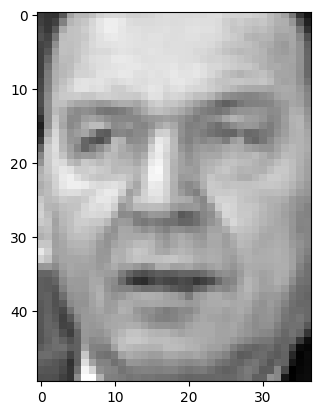

In [26]:
#Lectura base de datos
lfw_people = fetch_lfw_people(min_faces_per_person=70, resize=0.4)
# datos tipo pandas
Xdata = pd.DataFrame(lfw_people.data)/255
y = lfw_people.target
print('Dimensiones tipo pandas: ',Xdata.shape)
print('Dimensiones tipo imágen:',lfw_people.images.shape)
plt.imshow(np.array(Xdata.iloc[300,:]).reshape(lfw_people.images.shape[1],
                                             lfw_people.images.shape[2]),cmap='gray')
plt.show()

#**HoldOut evaluación**

- Se particiona el conjunto de datos en 80% para entrenamiento y 20% para evaluación.

In [30]:
# Partición 70/30
Xtrain, Xtest, ytrain, ytest = train_test_split(Xdata, y, test_size=0.3, random_state=123, stratify=y)
Xtrain.head()

,0,1,2,3,4,5,6,7,8,9,...,1840,1841,1842,1843,1844,1845,1846,1847,1848,1849
1015,0.001630,0.001661,0.001804,0.001902,0.001938,0.001984,0.002127,0.002194,0.002230,0.002302,...,0.001625,0.001728,0.002886,0.003568,0.003440,0.003204,0.002804,0.001646,0.000543,0.000410
106,0.000779,0.001077,0.001440,0.001707,0.001938,0.002215,0.002445,0.002553,0.002599,0.002686,...,0.002481,0.002548,0.002676,0.003055,0.003583,0.003804,0.003865,0.003886,0.003870,0.003850
105,0.001235,0.001374,0.001651,0.001666,0.001507,0.001543,0.001640,0.001738,0.001835,0.001943,...,0.001061,0.001241,0.001282,0.001415,0.002850,0.003409,0.003148,0.003142,0.003199,0.003142
849,0.001543,0.001866,0.002466,0.002727,0.002722,0.002609,0.002543,0.002548,0.002604,0.002640,...,0.002502,0.002358,0.003081,0.003660,0.003706,0.003686,0.002030,0.000559,0.000769,0.000851
812,0.001087,0.001358,0.001692,0.002061,0.002235,0.002466,0.002650,0.002671,0.002691,0.002748,...,0.001405,0.001635,0.001297,0.000272,0.000349,0.000420,0.000492,0.000559,0.000651,0.000672


#**3. Definir pipelines y espacios de búsqueda**

In [31]:
pipelines = [
    Pipeline([('nor', MinMaxScaler()), ('cla', LogisticRegression(max_iter=1000))]),
    Pipeline([('nor', MinMaxScaler()), ('cla', SGDClassifier(max_iter=1000))]),
    Pipeline([('nor', MinMaxScaler()), ('cla', SVC(probability=True))]),
    Pipeline([('nor', MinMaxScaler()), ('cla', RandomForestClassifier())]),
    Pipeline([('nor', MinMaxScaler()), ('cla', GaussianNB())]),
    Pipeline([('nor', MinMaxScaler()), ('cla', LinearDiscriminantAnalysis())]),
    Pipeline([('nor', MinMaxScaler()), ('cla', KNeighborsClassifier())])
]

search_spaces = [
    {'cla__C': Real(1e-3, 1e3, prior='log-uniform')},
    {'cla__alpha': Real(1e-4, 1e2, prior='log-uniform')},
    {'cla__C': Real(1, 1e4, prior='log-uniform'), 'cla__gamma': Real(1e-3, 10, prior='log-uniform')},
    {'cla__n_estimators': Integer(10, 200), 'cla__max_depth': Integer(1, 20), 'cla__max_features': Categorical(['sqrt', 'log2'])},
    {},
    {'cla__solver': Categorical(['svd'])},
    {'cla__n_neighbors': Integer(1, 20), 'cla__weights': Categorical(['uniform', 'distance']), 'cla__p': Integer(1, 2)}
]

label_models = ['Logistic', 'SGD', 'SVCrbf', 'RandomForest', 'NaiveBayes', 'LDA', 'KNN']


#**4. Optimización bayesiana y comparación**


🔍 Optimizando Logistic...

🔍 Optimizando SGD...

🔍 Optimizando SVCrbf...

🔍 Optimizando RandomForest...

🔍 Optimizando NaiveBayes...

🔍 Optimizando LDA...

🔍 Optimizando KNN...


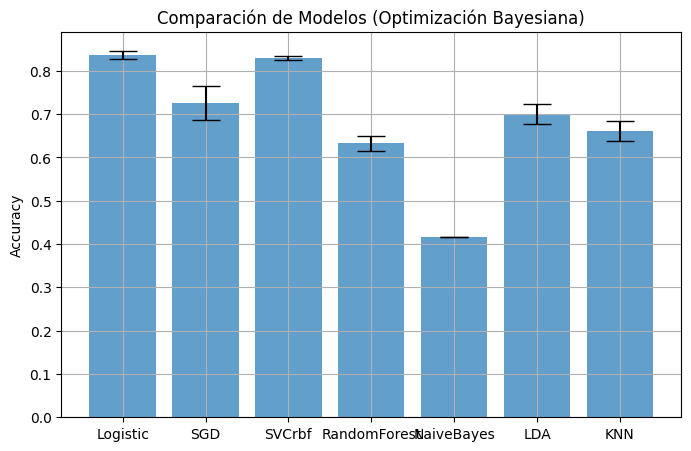

['modelos_bayes_7.pkl']

In [32]:
results = []
stds = []
models = []

for i, pipe in enumerate(pipelines):
    print(f"\n🔍 Optimizando {label_models[i]}...")

    if search_spaces[i]:
        opt = BayesSearchCV(pipe, search_spaces[i], n_iter=20, scoring='accuracy',
                            refit=True, cv=StratifiedKFold(5), n_jobs=-1, verbose=0)
        opt.fit(Xtrain, ytrain)
        best_model = opt
    else:
        pipe.fit(Xtrain, ytrain)
        best_model = pipe

    models.append(best_model)
    ypred = best_model.predict(Xtest)
    acc = accuracy_score(ytest, ypred)
    results.append(acc)

    if hasattr(best_model, 'cv_results_'):
        stds.append(best_model.cv_results_['std_test_score'][best_model.best_index_])
    else:
        stds.append(0.0)

# Visualización de barras
plt.figure(figsize=(8, 5))
plt.bar(np.arange(len(results)), results, yerr=stds, capsize=10, alpha=0.7)
plt.xticks(np.arange(len(label_models)), label_models)
plt.ylabel("Accuracy")
plt.title("Comparación de Modelos (Optimización Bayesiana)")
plt.grid(True)
plt.show()

# Guardar modelos
joblib.dump(models, 'modelos_bayes_7.pkl')


#**5: Funciones para evaluación final**

In [33]:
def plot_confusion_matrix(y_true, y_pred, classes, title='Confusion Matrix'):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=classes, yticklabels=classes, cmap='Blues')
    plt.title(title)
    plt.ylabel("True")
    plt.xlabel("Predicted")
    plt.tight_layout()
    plt.show()

def roc_multiclass(y_true_bin, y_score):
    fpr, tpr, roc_auc = {}, {}, {}
    for i in range(y_true_bin.shape[1]):
        fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_score[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
    return roc_auc, fpr, tpr

def plot_roc_multiclass(fpr, tpr, roc_auc, model_name):
    plt.figure(figsize=(10, 8))
    for i in range(len(roc_auc)):
        plt.plot(fpr[i], tpr[i], label=f'Clase {i} (AUC = {roc_auc[i]:.2f})')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.title(f'Curva ROC - {model_name}')
    plt.xlabel('FPR')
    plt.ylabel('TPR')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


#**6. Evaluación final con matriz de confusión y ROC**


📌 Logistic - ACC: 0.837
                   precision    recall  f1-score   support

     Ariel Sharon       0.88      0.65      0.75        23
     Colin Powell       0.87      0.86      0.87        71
  Donald Rumsfeld       0.72      0.78      0.75        37
    George W Bush       0.86      0.94      0.90       159
Gerhard Schroeder       0.85      0.67      0.75        33
      Hugo Chavez       0.93      0.67      0.78        21
       Tony Blair       0.74      0.79      0.76        43

         accuracy                           0.84       387
        macro avg       0.84      0.77      0.79       387
     weighted avg       0.84      0.84      0.83       387



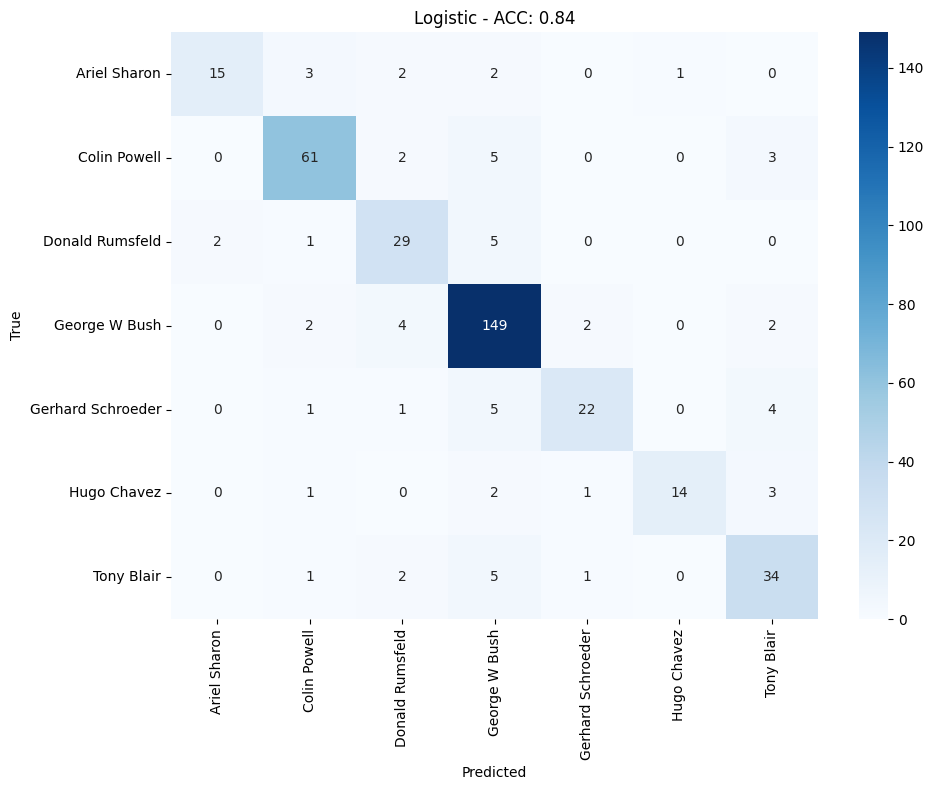

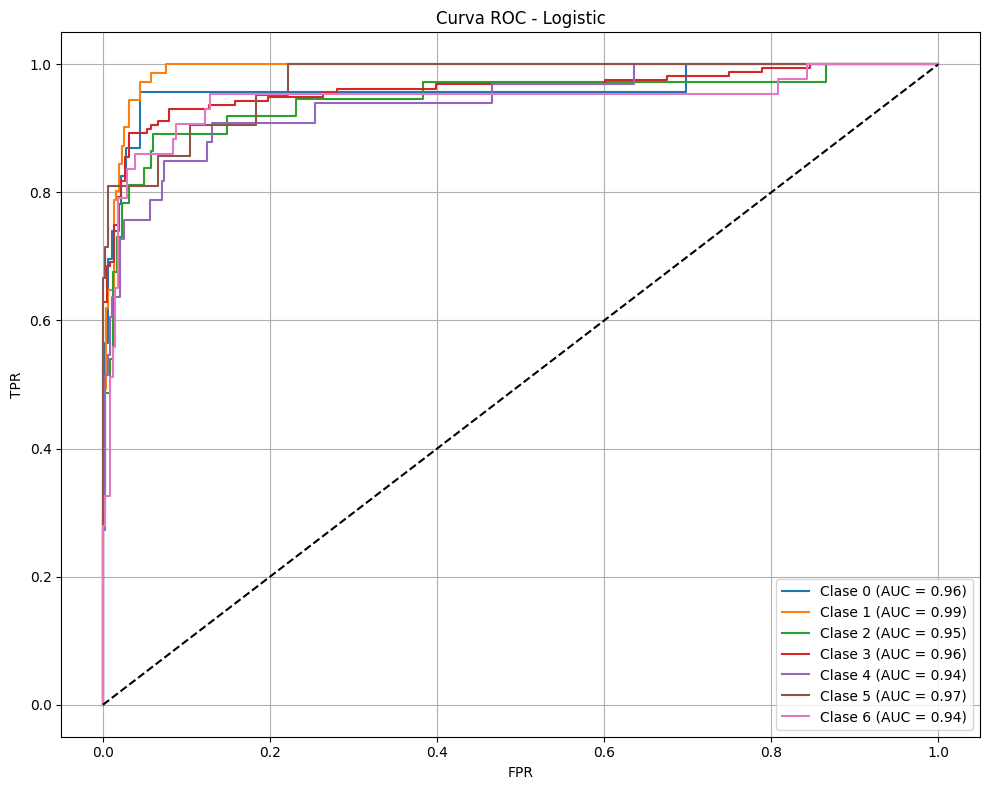


📌 SGD - ACC: 0.726
                   precision    recall  f1-score   support

     Ariel Sharon       0.86      0.52      0.65        23
     Colin Powell       0.90      0.61      0.72        71
  Donald Rumsfeld       0.71      0.78      0.74        37
    George W Bush       0.90      0.85      0.87       159
Gerhard Schroeder       1.00      0.18      0.31        33
      Hugo Chavez       0.88      0.71      0.79        21
       Tony Blair       0.37      0.95      0.53        43

         accuracy                           0.73       387
        macro avg       0.80      0.66      0.66       387
     weighted avg       0.83      0.73      0.73       387



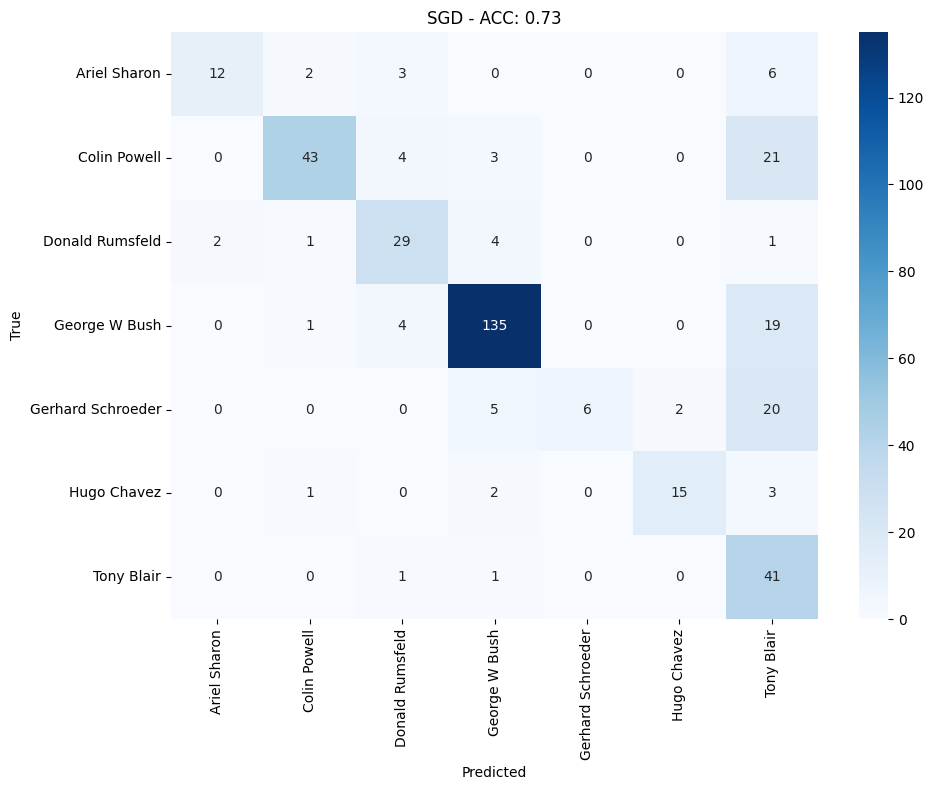

❌ No se pudo generar ROC para SGD: This 'Pipeline' has no attribute 'predict_proba'

📌 SVCrbf - ACC: 0.829
                   precision    recall  f1-score   support

     Ariel Sharon       0.68      0.74      0.71        23
     Colin Powell       0.85      0.89      0.87        71
  Donald Rumsfeld       0.75      0.65      0.70        37
    George W Bush       0.86      0.91      0.89       159
Gerhard Schroeder       0.78      0.64      0.70        33
      Hugo Chavez       0.94      0.71      0.81        21
       Tony Blair       0.80      0.84      0.82        43

         accuracy                           0.83       387
        macro avg       0.81      0.77      0.78       387
     weighted avg       0.83      0.83      0.83       387



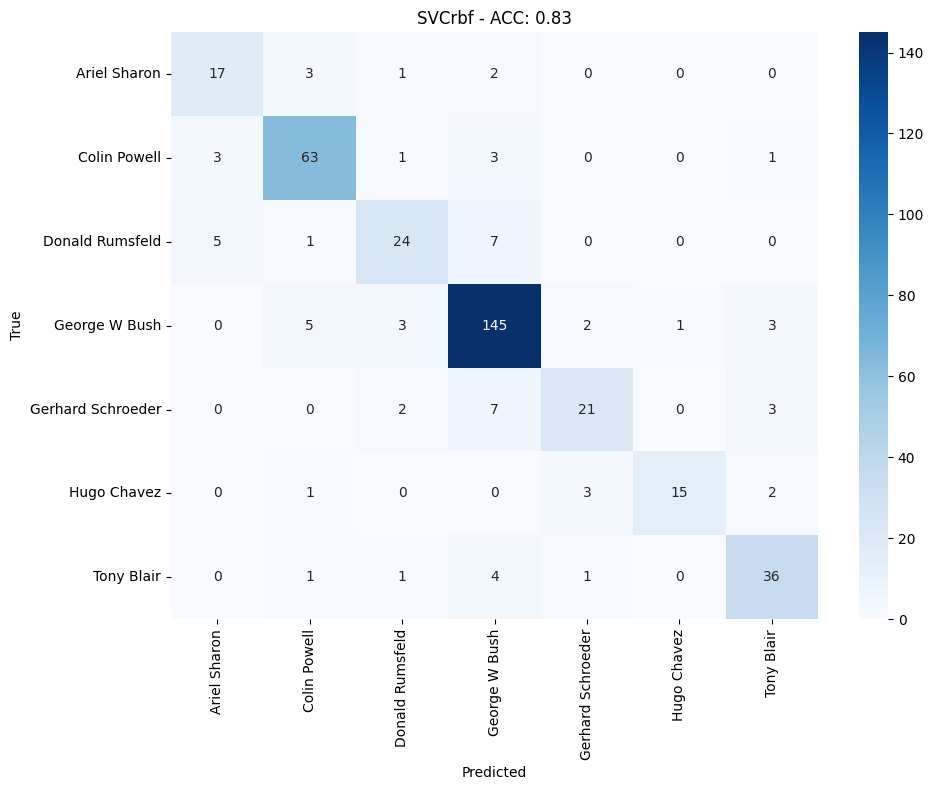

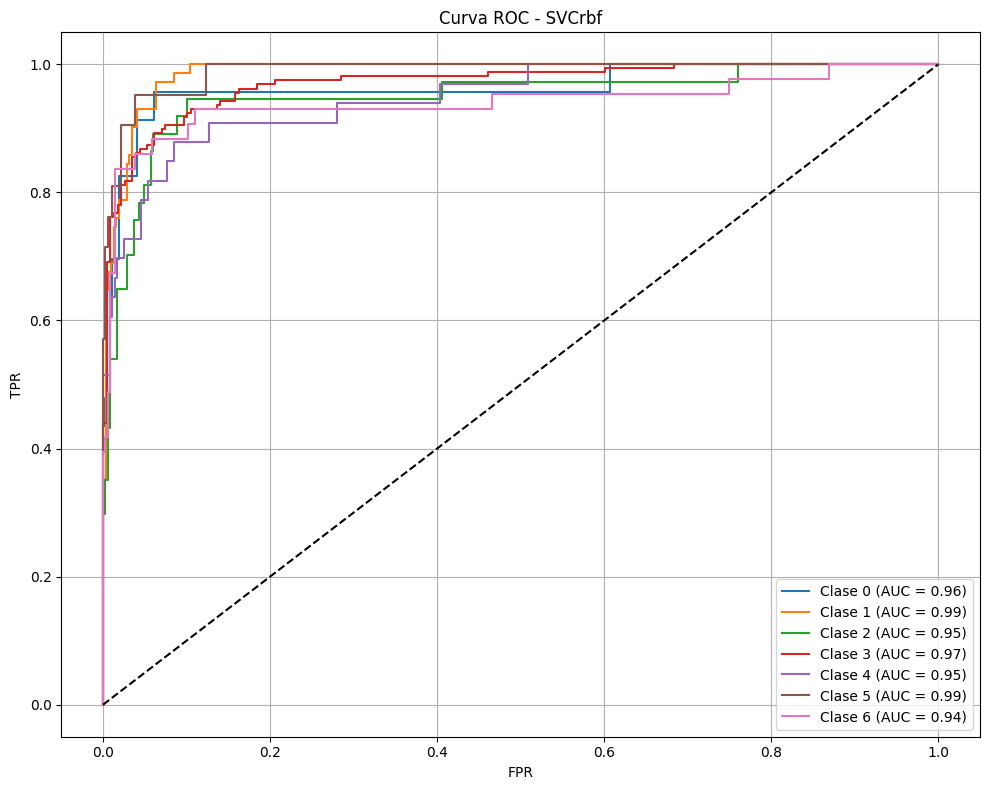


📌 RandomForest - ACC: 0.633
                   precision    recall  f1-score   support

     Ariel Sharon       0.00      0.00      0.00        23
     Colin Powell       0.77      0.76      0.77        71
  Donald Rumsfeld       0.83      0.27      0.41        37
    George W Bush       0.57      0.97      0.72       159
Gerhard Schroeder       0.67      0.18      0.29        33
      Hugo Chavez       1.00      0.24      0.38        21
       Tony Blair       0.79      0.35      0.48        43

         accuracy                           0.63       387
        macro avg       0.66      0.40      0.44       387
     weighted avg       0.65      0.63      0.57       387



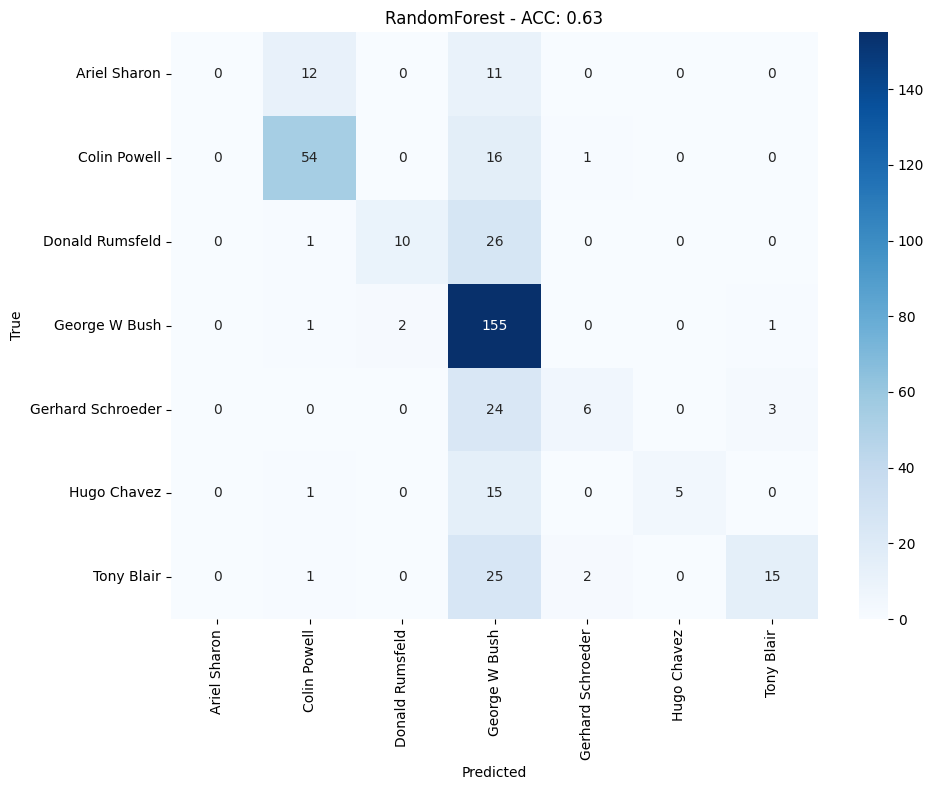

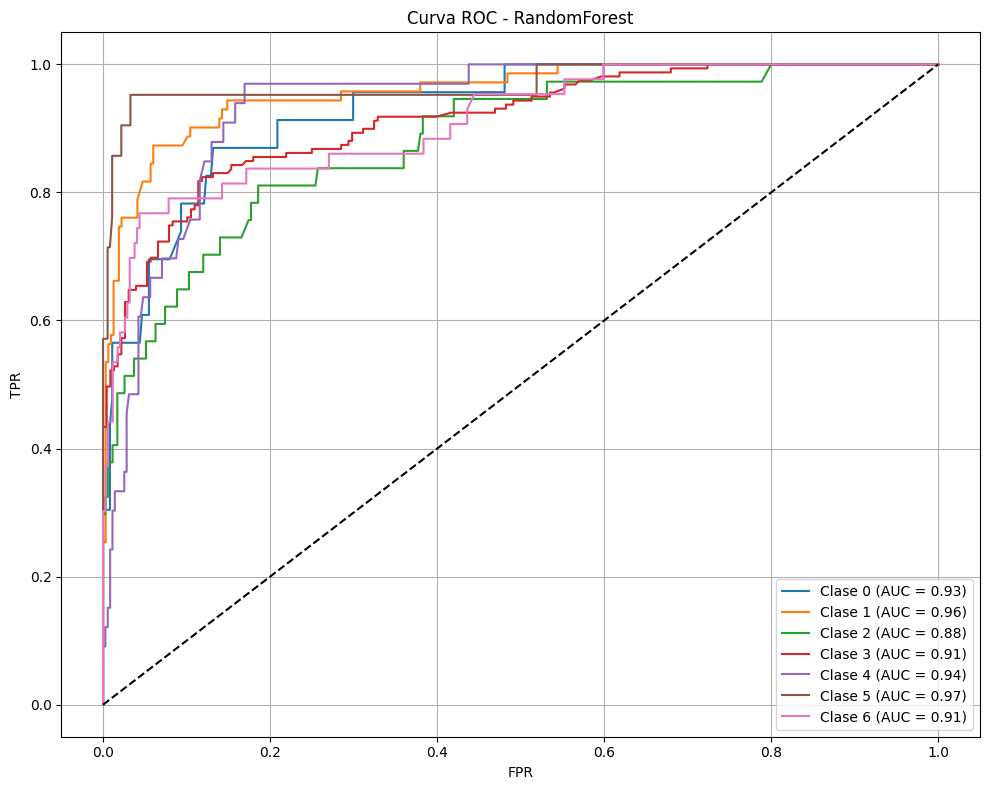


📌 NaiveBayes - ACC: 0.416
                   precision    recall  f1-score   support

     Ariel Sharon       0.33      0.43      0.38        23
     Colin Powell       0.51      0.51      0.51        71
  Donald Rumsfeld       0.47      0.49      0.48        37
    George W Bush       0.91      0.30      0.45       159
Gerhard Schroeder       0.17      0.33      0.23        33
      Hugo Chavez       0.23      0.71      0.35        21
       Tony Blair       0.33      0.53      0.41        43

         accuracy                           0.42       387
        macro avg       0.42      0.47      0.40       387
     weighted avg       0.60      0.42      0.43       387



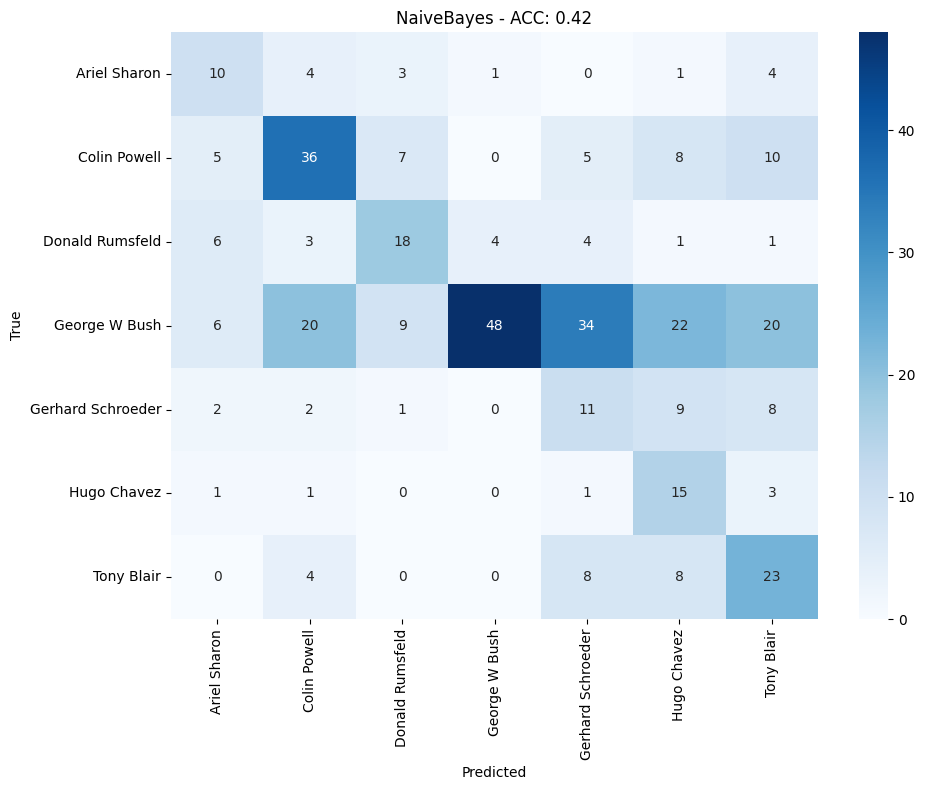

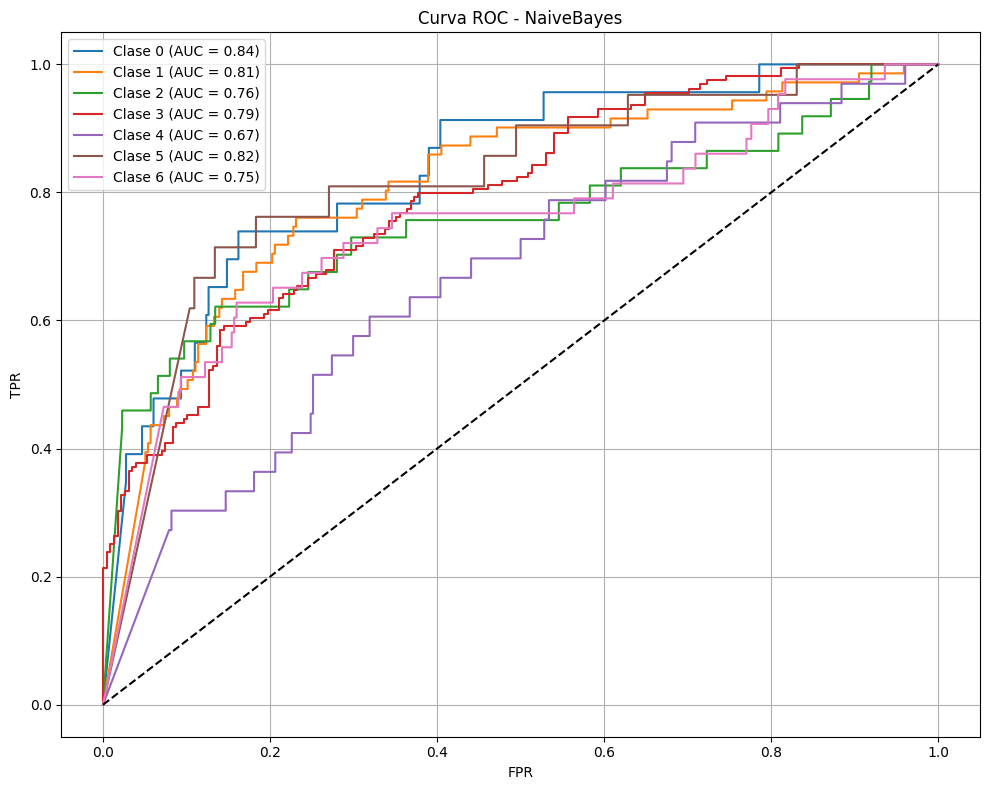


📌 LDA - ACC: 0.700
                   precision    recall  f1-score   support

     Ariel Sharon       0.69      0.39      0.50        23
     Colin Powell       0.73      0.68      0.70        71
  Donald Rumsfeld       0.56      0.65      0.60        37
    George W Bush       0.79      0.81      0.80       159
Gerhard Schroeder       0.54      0.58      0.56        33
      Hugo Chavez       0.58      0.71      0.64        21
       Tony Blair       0.68      0.63      0.65        43

         accuracy                           0.70       387
        macro avg       0.65      0.64      0.64       387
     weighted avg       0.70      0.70      0.70       387



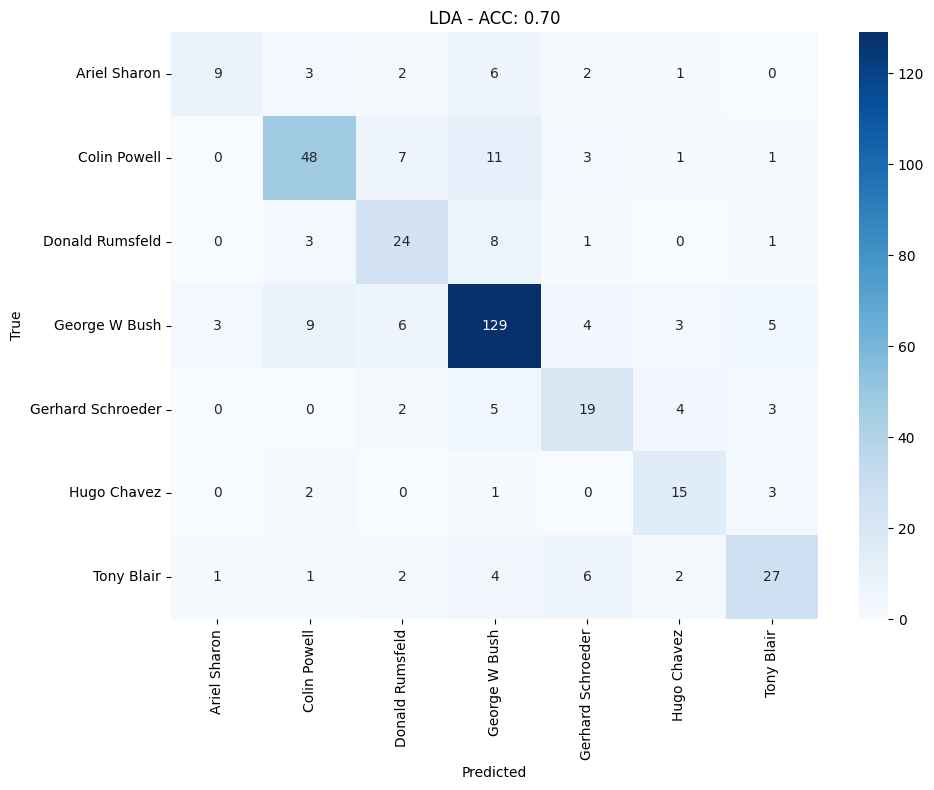

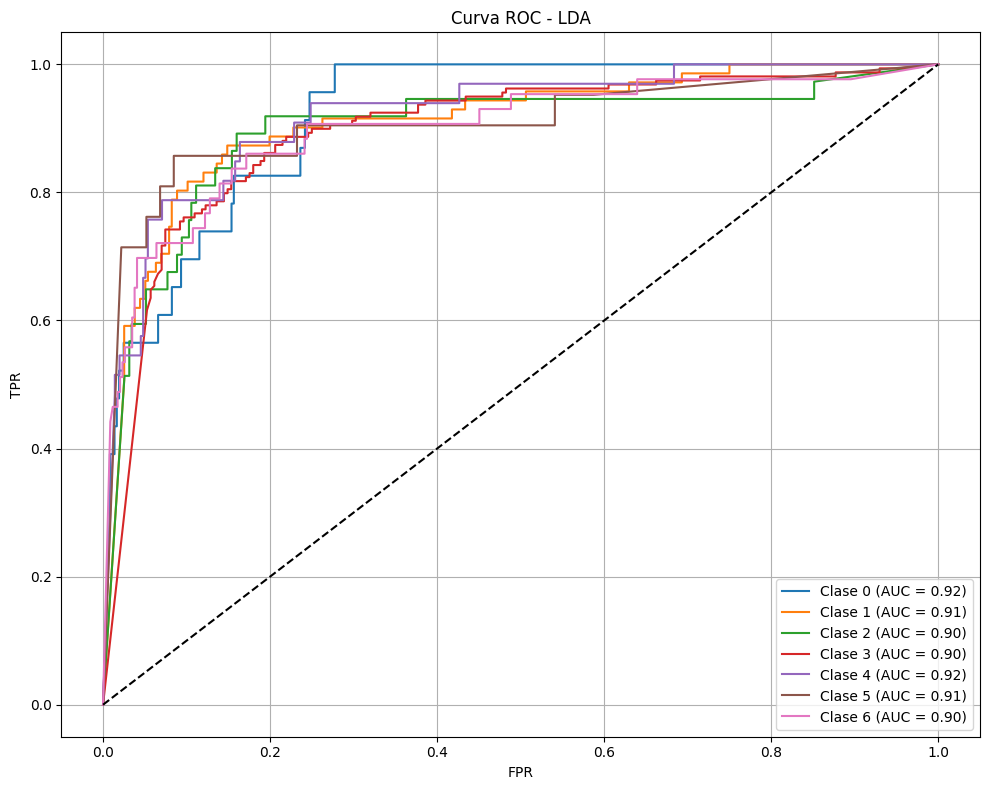


📌 KNN - ACC: 0.661
                   precision    recall  f1-score   support

     Ariel Sharon       0.75      0.39      0.51        23
     Colin Powell       0.68      0.70      0.69        71
  Donald Rumsfeld       0.72      0.57      0.64        37
    George W Bush       0.69      0.85      0.76       159
Gerhard Schroeder       0.46      0.39      0.43        33
      Hugo Chavez       0.50      0.29      0.36        21
       Tony Blair       0.61      0.51      0.56        43

         accuracy                           0.66       387
        macro avg       0.63      0.53      0.56       387
     weighted avg       0.66      0.66      0.65       387



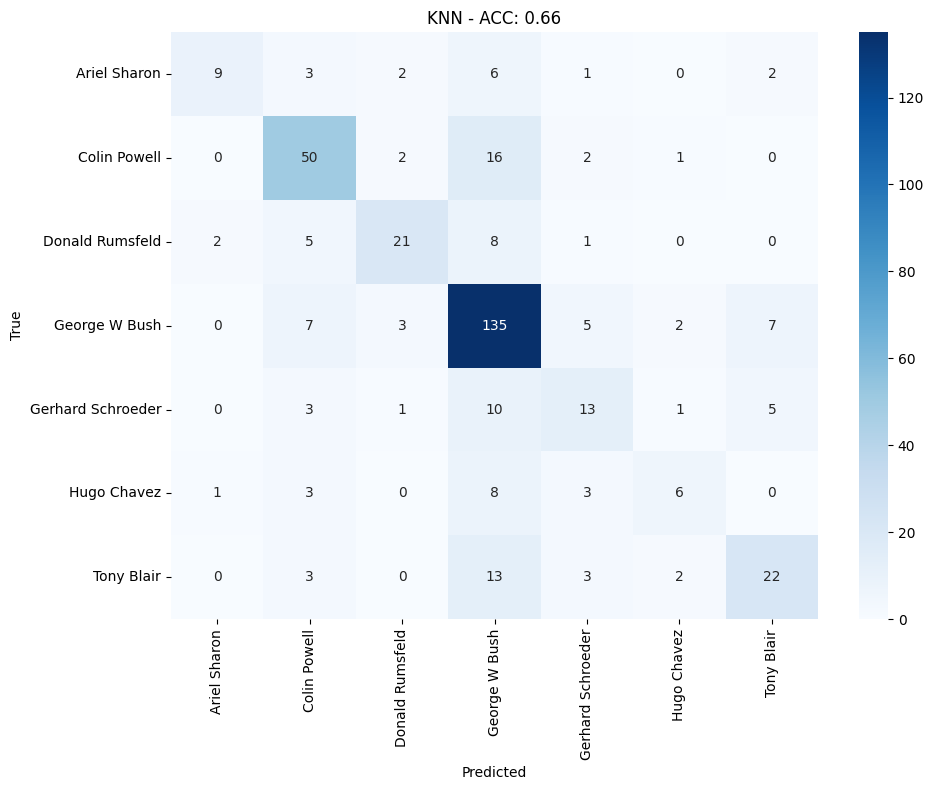

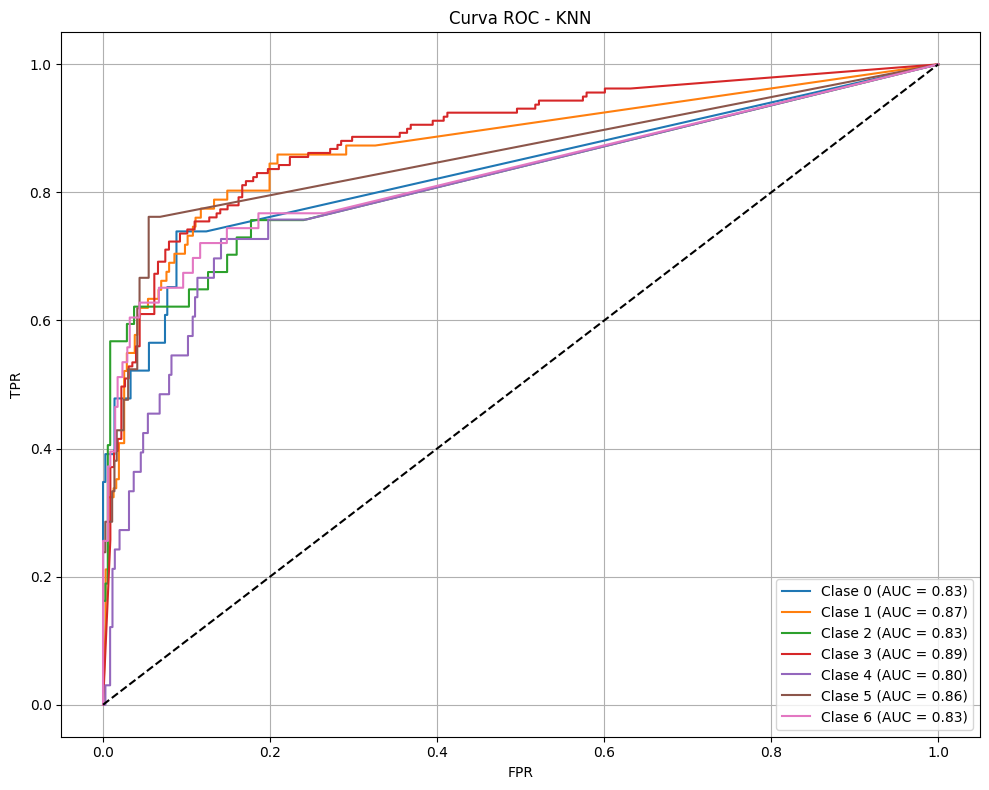

In [34]:
modelos_cargados = joblib.load('modelos_bayes_7.pkl')
ytest_bin = label_binarize(ytest, classes=np.unique(y))

for i, model in enumerate(modelos_cargados):
    name = label_models[i]
    est = model.best_estimator_ if hasattr(model, 'best_estimator_') else model
    y_pred = est.predict(Xtest)
    acc = accuracy_score(ytest, y_pred)

    print(f"\n📌 {name} - ACC: {acc:.3f}")
    print(classification_report(ytest, y_pred, target_names=lfw_people.target_names))
    plot_confusion_matrix(ytest, y_pred, lfw_people.target_names, title=f"{name} - ACC: {acc:.2f}")

    try:
        y_score = est.predict_proba(Xtest)
        if y_score.shape[1] == ytest_bin.shape[1]:
            roc_auc, fpr, tpr = roc_multiclass(ytest_bin, y_score)
            plot_roc_multiclass(fpr, tpr, roc_auc, name)
        else:
            print("⚠️ Clases no coinciden, se omite curva ROC.")
    except Exception as e:
        print(f"❌ No se pudo generar ROC para {name}: {e}")


#**7. Generación de tabla comparativa de rendimiento para los 7 clasificadores clasicos**

In [35]:
from sklearn.metrics import f1_score, roc_auc_score

tabla_resultados = []

ytest_bin = label_binarize(ytest, classes=np.unique(y))

for i, model in enumerate(models):
    name = label_models[i]
    est = model.best_estimator_ if hasattr(model, 'best_estimator_') else model

    y_pred = est.predict(Xtest)
    acc = accuracy_score(ytest, y_pred)
    f1 = f1_score(ytest, y_pred, average='macro')

    try:
        y_score = est.predict_proba(Xtest)
        auc_score = roc_auc_score(ytest_bin, y_score, average='macro', multi_class='ovr')
    except:
        auc_score = np.nan

    tabla_resultados.append({
        'Modelo': name,
        'Accuracy': acc,
        'F1 Score': f1,
        'AUC Score': auc_score
    })

df_resultados = pd.DataFrame(tabla_resultados)
df_resultados = df_resultados.sort_values(by='Accuracy', ascending=False).reset_index(drop=True)
display(df_resultados)


,Modelo,Accuracy,F1 Score,AUC Score
0,Logistic,0.837209,0.793382,0.959296
1,SVCrbf,0.829457,0.784113,0.963797
2,SGD,0.726098,0.659764,NaN
3,LDA,0.700258,0.635316,0.907739
4,KNN,0.661499,0.563957,0.844716
5,RandomForest,0.633075,0.435368,0.927946
6,NaiveBayes,0.416021,0.401950,0.776425
